<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II

## Tensões e deformações plásticas

### Problema 3

A viga oca cuja secção transversal se mostra na figura é feita em aço e está submetida à flexão em torno do eixo horizontal. Considere que o aço é um material com comportamento elastoplástico com $E = 210$ GPa e $\sigma_C =$ 280 MPa.

a) Determine o momento fletor e o raio de curvatura para o qual a espessura das zonas plastificadas é igual a 20 mm.

b) Determine a distribuição de tensões residuais na secção e o raio de curvatura residual depois do momento fletor anterior ser aplicado e posteriormente retirado.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au03/P3/MSII_Au03_P3.png"
width="400">

#### Formulário de base

- Momento fletor (limite elástico):

\begin{equation*}
\sigma_{xx} = - \frac{M_z}{I_z} y
\quad\Leftrightarrow\quad
\sigma_\mathrm{ced} = \frac{M_z}{I_z} y_\mathrm{max}
\quad\textrm{(T)}
\quad\therefore\quad
M_{\mathrm{C}} = \frac{\sigma_\mathrm{ced} I_z}{y_{\textrm{max}}}
\end{equation*}

- Raio de curvatura:
  
\begin{equation*}
\frac{1}{\rho} = \frac{\varepsilon_{xx}}{y}
\quad\wedge\quad
\varepsilon_{xx} = \frac{\sigma_{xx}}{E}
\quad\therefore\quad
\frac{1}{\rho} = \frac{\sigma_{xx}}{y} = \frac{M_z}{E I_z}
\end{equation*}

- Raio de curvatura na transição elástico-plástica:

\begin{equation*}
\frac{1}{\rho_p} = \frac{\varepsilon_{xx}^\mathrm{ced}}{y_\mathrm{e-p}}
\quad\wedge\quad
\varepsilon_{xx}^\mathrm{ced} = \frac{\sigma_\mathrm{ced}}{E}
\quad\therefore\quad
\frac{1}{\rho_C} = \frac{\sigma_{xx}^\mathrm{ced}}{y_\mathrm{e-p}} = \frac{M_\mathrm{C}}{E I_z}
\end{equation*}

#### Dados do problema

In [1]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
import matplotlib.pyplot as plt
import os

cor = '2'
if cor == '1':
    plt.rcParams['axes.facecolor'] = (.15, .15, .15)
    plt.rcParams['figure.facecolor'] = (.15, .15, .15)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.8, .8, .8),
              "xtick.color" : (.8, .8, .8),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.7, .7, .7),
              "axes.labelcolor" : (.8, .8, .8),
              "axes.edgecolor" : (.15, .15, .15)}
else:
    plt.rcParams['axes.facecolor'] = (.7, .7, .7)
    plt.rcParams['figure.facecolor'] = (.7, .7, .7)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.1, .1, .1),
              "xtick.color" : (.1, .1, .1),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.1, .1, .1),
              "axes.labelcolor" : (.1, .1, .1),
              "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)


# data structure, units: N, mm, MPa
# Create an empty class

class varin: pass

S = varin()

S.l1 = 10. # mm
S.l2 = 20. # mm
S.lt = 2*S.l1 + S.l2
print(f'total length: l = {S.lt:.0f} mm')

S.h1 = 20. # mm
S.ht = 3*S.h1
print(f'total width : h = {S.ht:.0f} mm')

E = 210e3 # unit: MPa
SigC = 280 # unit: MPa
yplast = 20 # unit: mm

total length: l = 40 mm
total width : h = 60 mm


# Resolução

## a) Determine o momento fletor e o raio de curvatura para o qual a espessura das zonas plastificadsa é igual a 20 mm.

### **Raio de curvatura:**


- Posição do centroide da secção

Pela dupla simetria da secção, o localização ($y_c, z_c$) do centroide é bem definida geometricamente.

- Momento de inércia de área

O momento de inércia de área para a secção transversal enunciada deve ser calculado em relação aos eixos principais de inércia da secção, com origem na posição do centroide da secção. Neste caso, portanto, não é necessário recorrer ao teorema dos eixos paralelos, pois o formulário aplica-se diretamente.

In [2]:
def irect(b,h): return b*h**3/12

print(':: area of major rectangular ::')
Iz1 = irect(S.lt*1e-3,S.ht*1e-3)
print(f'Iz1  = {Iz1:.4e} m⁴')

print(':: area of minor rectangular ::')
Iz2 = irect(S.l2*1e-3,S.h1*1e-3)
print(f'Iz2  = {Iz2:.4e} m⁴')

print(':: total ::')
Iz = Iz1 - Iz2
print(f'Iz  = {Iz:.4e} m⁴')

:: area of major rectangular ::
Iz1  = 7.2000e-07 m⁴
:: area of minor rectangular ::
Iz2  = 1.3333e-08 m⁴
:: total ::
Iz  = 7.0667e-07 m⁴


- Momento fletor (limite elástico):

\begin{equation*}
M_{\mathrm{C}} = \frac{\sigma_\mathrm{ced} I_z}{y_{\textrm{max}}}
\end{equation*}

In [3]:
ymax = S.ht/2*1e-3
print(f'ymax = {ymax:.3f} m')
MzC = SigC*1e6*Iz/ymax # Pa.m⁴/m = N.m⁴/m³ = N .m
print(f'MzC  = {SigC*1e6:.3e}({Iz:.3e})/{ymax:.2f} = {MzC:.2f} N.m = {MzC*1e-3:.2f} kN.m ')

ymax = 0.030 m
MzC  = 2.800e+08(7.067e-07)/0.03 = 6595.56 N.m = 6.60 kN.m 


- Raio de curvatura no limite elástico

\begin{equation*}
\frac{1}{\rho_C} = \frac{M_\mathrm{C}}{E I_z}
\end{equation*}

In [4]:
import sympy as sy

rho = sy.symbols('rho')

EQ = 1/rho - MzC/E*1e-6/Iz # N.m/(Pa.m⁴) = N.m/(N/m².m⁴)=1/m
print(f' radius : {EQ} [m]')

sol = sy.solve(EQ, rho)
rhoC = sol[0]
print(f' rhoC : {rhoC:.1f} [m]')

 radius : -0.0444444444444444 + 1/rho [m]
 rhoC : 22.5 [m]


- raio de curvatura no ponto de limite elástico (início da plastificação):

\begin{equation*}
\frac{1}{\rho}_p = \frac{\varepsilon_{xx}^\mathrm{ced}}{y_\mathrm{e-p}}
\quad\wedge\quad
\varepsilon_{xx}^\mathrm{ced} = \frac{\sigma_\mathrm{ced}}{E}
\end{equation*}

In [5]:
epsCed = SigC/E # unit: MPa / MPa
print(f'eps.Ced = {epsCed:.1e} [-] = {epsCed*1e6:.1f} [microdef]')

yced = S.ht/2-yplast
print(f' yced = {S.ht / 2:.1f} - {yplast:.1f} = {yced:.1f} [mm] = {yced*1e-3:.3f} [m]')

EQp = 1/rho - epsCed/(yced*1e-3) # N.m/(Pa.m⁴) = N.m/(N/m².m⁴)=1/m
print(f' radius plastic : {EQp} [m]')

sol1 = sy.solve(EQp, rho)
rhoP = sol1[0]
print(f' rhoP : {rhoP:.1f} [m]')

eps.Ced = 1.3e-03 [-] = 1333.3 [microdef]
 yced = 30.0 - 20.0 = 10.0 [mm] = 0.010 [m]
 radius plastic : -0.133333333333333 + 1/rho [m]
 rhoP : 7.5 [m]


### **Momento fletor:**

Nota: o valor do momento fletor máximo elástico, $M_\mathrm{C}$, e o correspondente raio de curvatura, $\rho$, são determinados no ponto limite de elasticidade. Ou seja, para obter o raio de curvatura, deve-se sempre considerar o ponto que marca a transição entre o núcleo elástico e a zona plastificada.

Neste caso, ocorre plasticidade parcial na secção correspondente a uma altura de 20 mm. Desta forma, deve-se determinar o momento fletor e o raio de curvatura resultantes.

Para tal, considere-se a força resultante que atua em cada uma das sub-regiões, elástica e plástica. É importante notar que na zona plástica, a tensão normal é constante, de acordo com o modelo constitutivo elasto-plástico, enquanto que na zona elástica, a tensão normal varia linearmente com a coordenada $y$, sendo nula sobre o eixo neutro.

- Para metada da secção da viga, o sumátorio os momentos de flexão gerados pela resultante das forças em relação ao eixo neutro é dado por:

\begin{equation*}
\sum M_\textrm{sup} = R_e \cdot d_e + R_p \cdot d_p
\end{equation*}

- Região plástica:

\begin{equation*}
R_p^\Box = \sigma_\mathrm{ced}\cdot A_p
\quad\wedge\quad A_p^\Box = l_t\cdot y_p
\end{equation*}

- Região elástica:

\begin{equation*}
R_e^\triangle = (\sigma_\mathrm{ced}\cdot A_e)/2
\quad\wedge\quad A_e = 2(l_1\cdot h_1/2)
\end{equation*}

In [6]:
print(':: plastic region : normal stress equals admissible stress of the material ::')
Ap = S.lt*yplast*1.e-6
print(f'Ap = {S.lt:.1f}({yplast:.1f})x1.e-6 = {Ap*1e6:.1f} [mm²] = {Ap:.1e} [m²]')
Rp = SigC*1.e6*Ap # unit: N/m² + m²
print(f'Rp = {SigC}x1.e6({Ap:.2e}) =  {Rp:.1f} [N] = {Rp*1e-3:.1f} [kN]')

print('\n:: elastic region : normal stress varies linearly with y ::')
Ae = 2*(S.l1*(S.h1/2)*1.e-6)
print(f'Ae = 2[{S.l1}({S.h1 / 2})x1.e-6] = {Ae*1e6:.1f} [mm²] = {Ae:.1e} [m²]')
Re = SigC*1e6*Ae/2 # unit: N/m² + m²
print(f'Re = ({SigC:.1f}x1.e6)({Ae:.3e})/2 = {Re:.1f} [N] = {Re*1e-3:.1f} [kN]')

:: plastic region : normal stress equals admissible stress of the material ::
Ap = 40.0(20.0)x1.e-6 = 800.0 [mm²] = 8.0e-04 [m²]
Rp = 280x1.e6(8.00e-04) =  224000.0 [N] = 224.0 [kN]

:: elastic region : normal stress varies linearly with y ::
Ae = 2[10.0(10.0)x1.e-6] = 200.0 [mm²] = 2.0e-04 [m²]
Re = (280.0x1.e6)(2.000e-04)/2 = 28000.0 [N] = 28.0 [kN]


Em que a distância $d_i~(i=e,p)$ é medida entre o centroide de cada sub-área ao eixo neutro:

- Região plástica:


\begin{equation*}
d_p^\Box = h_1/2 + h_1/2 = h_1
\end{equation*}

- Região elástica:

\begin{equation*}
d_e^\triangle = (h_1/2)\frac{2}{3}
\end{equation*} 

In [7]:
print(':: plastic region : normal stress equals admissible stress of the material ::')
dp = S.h1/2 + S.h1/2
print(f'dp = {dp:.1f} [mm] = = {dp*1e-3:.3f} [m]')

print('\n:: elastic region : normal stress varies linearly with y ::')
de = 2/3*(S.h1/2)
print(f'de = 2/3({S.h1:.1f}/2) = {de:.1f} [mm] = = {de*1e-3:.3f} [m]')

:: plastic region : normal stress equals admissible stress of the material ::
dp = 20.0 [mm] = = 0.020 [m]

:: elastic region : normal stress varies linearly with y ::
de = 2/3(20.0/2) = 6.7 [mm] = = 0.007 [m]


In [8]:
print('\nMomento fletor total (parte suparior)::::::::::::::::::')
Mp = Rp*dp*1e-3
print(f'Mp = ({Rp:.1f})({dp:.1f})x1.e-3 = {Mp:.1f} [N.m] = {Mp*1e-3:.3f} [kN.m]')

Me = Re*de*1.e-3
print(f'Me = ({Re:.1f})({de:.2f})x1.e-3 = {Me:.1f} [N.m] = {Me*1e-3:.3f} [kN.m]')

Mtup = Me + Mp
print(f'Mtup = {Rp:.1f}({dp:.1f}) + {Re:.1f}({de:.1f}) = {Mtup:.1f} [N.m] = {Mtup*1e-3:.3f} [kN.m]')


Momento fletor total (parte suparior)::::::::::::::::::
Mp = (224000.0)(20.0)x1.e-3 = 4480.0 [N.m] = 4.480 [kN.m]
Me = (28000.0)(6.67)x1.e-3 = 186.7 [N.m] = 0.187 [kN.m]
Mtup = 224000.0(20.0) + 28000.0(6.7) = 4666.7 [N.m] = 4.667 [kN.m]


- O momento fletor total é determinado comtabilizando as duas regiões simétricas do problema:

\begin{equation*}
M_t = M_\textrm{sup} + M_\textrm{inf}
\end{equation*}

In [9]:
Mt = 2*Mtup
print(f'Mt = 2(Rp.dp + Re.de) = {Mt:.1f} [N.m] = {Mt*1e-3:.3f} [kN.m]')

Mt = 2(Rp.dp + Re.de) = 9333.3 [N.m] = 9.333 [kN.m]


#### b) Determine a distribuição de tensões residuais na secção e o raio de curvatura residual depois do momento fletor anterior ser aplicado e posteriormente retirado.

Para a anáilse das tensões residuais recorre-se ao **princípio da sobrepoisição** contabilizando:

1. O carregamento real, onde a parte central da secção tem comportamento elástico (tensão normal varia linearmente) e em que a parte periférica ($y$=20 mm) está em plasticidade (tensão normal igual à tensão de cedência do material de acordo com a lei constitutiva elasto-plástica perfeita);

2. Um carregamento hipotético considerando a tensão normal a que a secção estaria submetida para o momento fletor máximo (plástico), assumindo sempre um comportamento no domínio elástico, com sentido contrário ao real (correspondendo a um cenário de descarregamento da momento fletor aplicado).

- Dados: Momento fletor plástico, coordenada $y_\textrm{max}$

Calcular a tensão normal que seria gerada pelo valor do momento fletor plástico, assumindo, por hipótese, um comprtamento linear

\begin{equation*}
\sigma_{m} = \frac{M_p}{I_z} y_\mathrm{max}
\end{equation*}

In [10]:
print('-------------------------------------------------------')
ymaxTR = S.ht/2
print(f' ymaxTR = {ymaxTR:.1f} [mm] = {ymaxTR*1e-3:.3f} [m]')
SigMaxTR = Mt/Iz*(ymaxTR*1.e-3)
print(f' SmaxTR = ({Mt:.1f}/{Iz:.3e})({ymaxTR}x1.e-3) = {SigMaxTR:.1f} [Pa] = {SigMaxTR*1e-6:.1f} [MPa]')
print('-------------------------------------------------------')

print(':: moment at the transition point between elastic and plastic regions (complemento) ::')
MzC2 = SigC*1e6*Iz/(S.h1/2*1e-3)
print(f' Mf.e-p (y.e-p) : {MzC2:.1f} [N.m] = {MzC2*1e-3:.3f} [kN.m]')


-------------------------------------------------------
 ymaxTR = 30.0 [mm] = 0.030 [m]
 SmaxTR = (9333.3/7.067e-07)(30.0x1.e-3) = 396226415.1 [Pa] = 396.2 [MPa]
-------------------------------------------------------
:: moment at the transition point between elastic and plastic regions (complemento) ::
 Mf.e-p (y.e-p) : 19786.7 [N.m] = 19.787 [kN.m]


- Avaliação da tensão residual em pontos de interesse:


In [11]:
def evaltres(j,yc):
    if np.abs(j) >= S.h1/2: # plastic region
        print('::plastic region::')
        if j >= 0:
            # y.pos: (- : compression-real) | (+ : tension-hypo)
            real, imag = - SigC*1e6, Mt/Iz*(j*1e-3)
        else:
            # y.neg: (+ : tension-real) | (- : compression-hypo)
            real, imag = SigC*1e6, Mt/Iz*(j*1e-3)
        print(f'({real*1e-6:.1f} , {imag*1e-6:.1f}) [MPa]')
    else: # elastic region
        print('::elastic region::')
        real, imag = - MzC2/Iz*(j*1e-3), Mt/Iz*(j*1e-3)
        print(f'({real*1e-6:.1f} , {imag*1e-6:.1f}) [MPa]')
    return  real + imag

print('-------------------------------------------------------')
y1 = S.ht/2 # unit: mm
print(f'y1 : {y1:.1f} [mm] = {y1*1e-3:.3f} [m]')
sr1 = evaltres(y1,yplast)
print(f'Sxx.residual (y1) : {sr1*1e-6:.1f} [MPa]')

-------------------------------------------------------
y1 : 30.0 [mm] = 0.030 [m]
::plastic region::
(-280.0 , 396.2) [MPa]
Sxx.residual (y1) : 116.2 [MPa]


In [12]:
print('-------------------------------------------------------')
y2 = S.h1/2 # unit: mm
print(f'y2 : {y2:.1f} [mm] = {y2*1e-3:.3f} [m]')
sr2 = evaltres(y2,yplast)
print(f'Sxx.residual (y2) : {sr2*1e-6:.1f} [MPa]')

-------------------------------------------------------
y2 : 10.0 [mm] = 0.010 [m]
::plastic region::
(-280.0 , 132.1) [MPa]
Sxx.residual (y2) : -147.9 [MPa]


In [13]:
print('-------------------------------------------------------')
y3 = -y2  # unit: mm
print(f'y3 : {y3:.1f} [mm] = {y3*1e-3:.3f} [m]')
sr3 = evaltres(y3,yplast)
print(f'Sxx.residual (y3) : {sr3*1e-6:.1f} [MPa]')

-------------------------------------------------------
y3 : -10.0 [mm] = -0.010 [m]
::plastic region::
(280.0 , -132.1) [MPa]
Sxx.residual (y3) : 147.9 [MPa]


In [14]:
print('-------------------------------------------------------')
y4 = -y1  # unit: mm
print(f'y4 : {y4:.1f} [mm] = {y4*1e-3:.3f} [m]')
sr4 = evaltres(y4,yplast)
print(f'Sxx.residual (y4) : {sr4*1e-6:.1f} [MPa]')

-------------------------------------------------------
y4 : -30.0 [mm] = -0.030 [m]
::plastic region::
(280.0 , -396.2) [MPa]
Sxx.residual (y4) : -116.2 [MPa]


- Visualização dos perfis de tensão (princípio da sobreposição), incluindo a tensão residual:

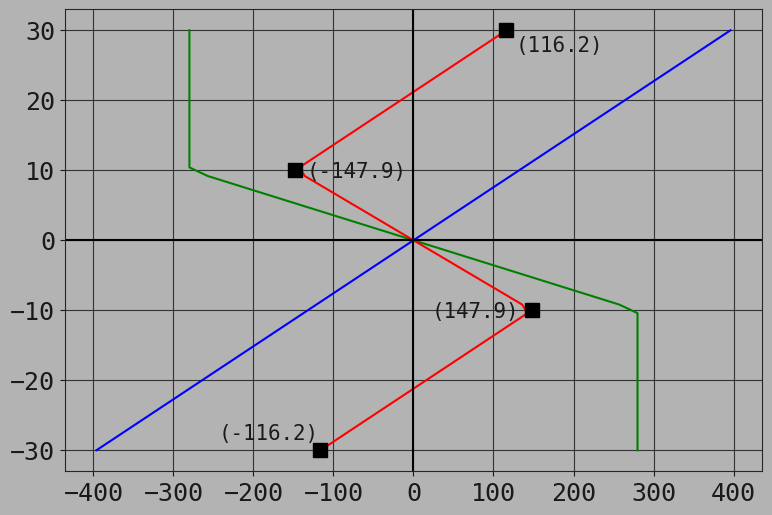

In [15]:

def sreal2plo(j):
    if np.abs(j) >= S.h1/2: # plastic region
        if j >= 0:
            real = - SigC*1e6
        else:
            real = SigC*1e6
    else: # elastic region
        real = - MzC2/Iz*(j*1e-3)
    return  real

def simg2plo(j):
    return Mt/Iz*(j*1e-3)

yplo = np.linspace(-S.ht/2,S.ht/2) # unit: mm
sRplo = np.zeros(len(yplo))
for j in range(0,len(yplo)):
    sRplo[j] = sreal2plo(yplo[j])*1e-6

sIplo = simg2plo(yplo)*1e-6

#initialize a plot
ax = plt.figure(figsize=(9,6))
plt.plot(sRplo,yplo,'-g')
plt.plot(sIplo,yplo,'-b')
plt.plot(sRplo+sIplo,yplo,'-r')
plt.plot(sr1*1e-6,y1,'sk',markersize=10)
plt.text(sr1*1e-6*1.1,y1*.9,f'({sr1*1e-6:.1f})', fontsize=15)
plt.plot(sr2*1e-6,y2,'sk',markersize=10)
plt.text(sr2*1e-6*.9,y2*.9,f'({sr2*1e-6:.1f})', fontsize=15)
plt.plot(sr3*1e-6,y3,'sk',markersize=10)
plt.text(sr3*1e-6*.15,y3*1.1,f'({sr3*1e-6:.1f})', fontsize=15)
plt.plot(sr4*1e-6,y4,'sk',markersize=10)
plt.text(sr4*1e-6*2.1,y4*.95,f'({sr4*1e-6:.1f})', fontsize=15)
plt.axhline(y=0, color='k')
plt.axvline(x=0, color='k')
plt.grid()
plt.show()

- Raio de curvatura avaliado no ponto de transição elástico-plástico, $y_\mathrm{e-p}$

\begin{equation*}
\rho^\mathrm{max} = \frac{y_\mathrm{e-p}}{\varepsilon_{r}} = \frac{yE}{|\sigma_{r}^\mathrm{max}|}
\end{equation*}

In [16]:
rhoRmax = np.abs(y2*1e-3*E*1e6/sr2)
print(f'rho.residual.max (y2,Srmax) = ({y2*1e-3:.2f},|{np.abs(sr2*1e-6):.1f}|) : {rhoRmax:.1f} [m]')

rho.residual.max (y2,Srmax) = (0.01,|147.9|) : 14.2 [m]


---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>